# Product, Cross-Sell, Subscription, and Churn

Gold/Silver recreation of product, cross-sell, subscription LTV, churn, and related visualization inputs.


In [1]:
from pathlib import Path
import os
import warnings
warnings.filterwarnings("ignore")

_BOOT_ROOT = Path.cwd()
_MPL_DIR = (_BOOT_ROOT / "outputs" / ".matplotlib") if _BOOT_ROOT.name == "notebooks" else (_BOOT_ROOT / "notebooks" / "outputs" / ".matplotlib")
_MPL_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(_MPL_DIR))
os.environ.setdefault("XDG_CACHE_HOME", str(_MPL_DIR.parent / ".cache"))

import numpy as np
import pandas as pd
import matplotlib
if os.environ.get("NOTEBOOK_VALIDATION") == "1":
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

try:
    from IPython.display import display, Markdown
except Exception:
    def display(x): print(x)
    def Markdown(x): return x

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = Path.cwd().resolve()

SILVER = PROJECT_ROOT / "data" / "silver"
GOLD = PROJECT_ROOT / "data" / "gold"
LEGACY_OUT = PROJECT_ROOT / "EDA" / "outputs"
NB_OUT = PROJECT_ROOT / "notebooks" / "outputs"
CHART_OUT = NB_OUT / "charts"
NB_OUT.mkdir(parents=True, exist_ok=True)
CHART_OUT.mkdir(parents=True, exist_ok=True)

ANALYSIS_DATE = pd.Timestamp("2026-04-30", tz="UTC")
MARGIN = 0.40

TEAL = "#2DC4A2"
NAVY = "#1A2E44"
SLATE = "#4A6274"
ORANGE = "#F07D3E"
RED = "#E84545"
GOLD_C = "#F7B731"
LILAC = "#9B72CF"
LIGHT_BG = "#F8F9FA"
CAT_COLORS = [TEAL, NAVY, ORANGE, GOLD_C, SLATE, RED, LILAC]
plt.rcParams.update({
    "figure.facecolor": LIGHT_BG,
    "axes.facecolor": LIGHT_BG,
    "axes.edgecolor": "#E2E8ED",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": "#E2E8ED",
    "axes.labelcolor": NAVY,
    "axes.titlecolor": NAVY,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "xtick.color": SLATE,
    "ytick.color": SLATE,
    "legend.frameon": False,
    "font.family": ["DejaVu Sans"],
})

def money(x):
    return f"S${x:,.0f}"

def pct(x):
    return f"{x:.1%}"

RECREATED_CHARTS = []

def save_chart(fig, name):
    RECREATED_CHARTS.append(name)
    if os.environ.get("NOTEBOOK_VALIDATION") == "1":
        fig.canvas.draw()
    else:
        display(fig)
    plt.close(fig)
    print(f"rendered inline: {name}")
    return name

def load_marts():
    orders = pd.read_parquet(SILVER / "orders.parquet").copy()
    customers = pd.read_parquet(GOLD / "customers.parquet").copy()
    lines = pd.read_parquet(GOLD / "order_lines_enriched.parquet").copy()
    recharge_orders = pd.read_parquet(GOLD / "recharge_orders_enriched.parquet").copy()
    silver = {
        "discounts": pd.read_parquet(SILVER / "discounts.parquet"),
        "products": pd.read_parquet(SILVER / "products.parquet"),
        "campaigns": pd.read_parquet(SILVER / "campaigns.parquet"),
        "recharge_checkout": pd.read_parquet(SILVER / "recharge_checkout_items.parquet"),
        "recharge_recurring": pd.read_parquet(SILVER / "recharge_recurring_items.parquet"),
        "recharge_churned": pd.read_parquet(SILVER / "recharge_churned.parquet"),
        "recharge_reactivated": pd.read_parquet(SILVER / "recharge_reactivated.parquet"),
        "recharge_orders": pd.read_parquet(SILVER / "recharge_orders.parquet"),
    }
    orders["order_date"] = pd.to_datetime(orders["order_date"], utc=True)
    customers["first_order_date"] = pd.to_datetime(customers["first_order_date"], utc=True)
    customers["last_order_date"] = pd.to_datetime(customers["last_order_date"], utc=True)
    customers["second_order_date"] = pd.to_datetime(customers["second_order_date"], utc=True, errors="coerce")
    lines["order_date"] = pd.to_datetime(lines["order_date"], utc=True)

    orders["primary_revenue_sgd"] = pd.to_numeric(orders["order_revenue_sgd"], errors="coerce").fillna(0)
    orders["legacy_total_incl_shipping_sgd"] = pd.to_numeric(orders["order_total_incl_shipping_sgd"], errors="coerce").fillna(0)
    orders["Price: Total"] = orders["legacy_total_incl_shipping_sgd"]
    orders["Price: Total Discount"] = pd.to_numeric(orders["order_discount_sgd"], errors="coerce").fillna(0)
    orders["Price: Total Shipping"] = pd.to_numeric(orders["shipping_revenue_sgd"], errors="coerce").fillna(0)
    orders["revenue_basis_delta_sgd"] = orders["legacy_total_incl_shipping_sgd"] - orders["primary_revenue_sgd"]

    customers["total_revenue"] = pd.to_numeric(customers["total_revenue_sgd"], errors="coerce").fillna(0)
    customers["total_discount"] = pd.to_numeric(customers["total_discount_sgd"], errors="coerce").fillna(0)
    customers["first_product_cat"] = customers["first_product_category"]
    customers["is_repeat"] = customers["is_repeat"].astype(bool)

    for col in ["Line: Quantity", "Line: Price", "Line: Discount", "Line: Total"]:
        if col in lines.columns:
            lines[col] = pd.to_numeric(lines[col], errors="coerce").fillna(0)
    return orders, customers, lines, recharge_orders, silver

orders, customers, lines, recharge_orders, silver = load_marts()
print(f"Loaded marts: {len(orders):,} orders, {len(customers):,} customers, {len(lines):,} enriched lines")
print("Primary revenue excludes shipping. Legacy comparability uses order_total_incl_shipping_sgd.")


Loaded marts: 27,350 orders, 13,780 customers, 50,963 enriched lines
Primary revenue excludes shipping. Legacy comparability uses order_total_incl_shipping_sgd.


## Product Stickiness and Cross-Sell


In [2]:
rep_by_prod = (
    customers.groupby("first_product_cat")
    .agg(customers=("customer_id", "count"), repeaters=("is_repeat", "sum"), avg_total_orders=("total_orders", "mean"), avg_ltv=("total_revenue", "mean"), median_days_2nd=("days_to_second", "median"))
    .assign(repeat_rate=lambda d: d.repeaters / d.customers)
    .sort_values("repeat_rate", ascending=False)
)
display(rep_by_prod)
rep_by_prod.to_csv(NB_OUT / "02_repeat_by_first_product.csv")

cat_per_cust = lines.groupby("customer_id")["product_category"].nunique().reset_index().rename(columns={"product_category": "n_categories"})
cat_per_cust["n_categories"] = cat_per_cust.n_categories.clip(upper=4)
cat_per_cust["category_label"] = cat_per_cust.n_categories.map({1:"1 product", 2:"2 products", 3:"3 products", 4:"4+ products"})
cross = customers.merge(cat_per_cust, on="customer_id", how="left")
cross["n_categories"] = cross.n_categories.fillna(1)
cross["category_label"] = cross.category_label.fillna("1 product")
cross_summary = cross.groupby("category_label").agg(customers=("customer_id", "count"), repeat_rate=("is_repeat", "mean"), avg_ltv=("total_revenue", "mean"), avg_orders=("total_orders", "mean"), avg_lifespan_days=("lifespan_days", "mean")).reindex(["1 product","2 products","3 products","4+ products"])
display(cross_summary)
cross_summary.to_csv(NB_OUT / "02_cross_product_ltv.csv")

prod_rev = lines.groupby("product_category").agg(total_units=("Line: Quantity", "sum"), total_revenue=("Line: Total", "sum"), n_orders=("order_id", "nunique"), n_customers=("customer_id", "nunique"), avg_unit_price=("Line: Price", "mean")).assign(revenue_per_customer=lambda d: d.total_revenue / d.n_customers).sort_values("total_revenue", ascending=False)
display(prod_rev)
prod_rev.to_csv(NB_OUT / "02_product_revenue_summary.csv")


,customers,repeaters,avg_total_orders,avg_ltv,median_days_2nd,repeat_rate
first_product_cat,,,,,,
Unknown,6908,2808,2.337435,332.320492,52.0,0.406485
Collagen Glow,439,137,1.908884,127.832739,48.0,0.312073
Other,2480,626,1.874194,137.753099,52.0,0.252419
Lean Protein,1324,307,1.444109,100.598999,36.0,0.231873
Clear Protein,1550,349,1.471613,108.338876,44.0,0.225161
Accessories,696,154,1.395115,67.857874,20.0,0.221264
Soy Protein,361,75,1.454294,87.766113,64.0,0.207756
Supplements,22,3,1.272727,104.187590,83.0,0.136364


,customers,repeat_rate,avg_ltv,avg_orders,avg_lifespan_days
category_label,,,,,
1 product,9529,0.236121,167.772593,1.480113,42.309162
2 products,2665,0.396623,223.398275,2.234897,198.474296
3 products,1056,0.649621,467.472201,3.411932,357.335227
4+ products,530,0.879245,732.126860,6.956604,573.543396


,total_units,total_revenue,n_orders,n_customers,avg_unit_price,revenue_per_customer
product_category,,,,,,
Unknown,42410.0,2.097600e+06,14312,7478,33.713709,280.502817
Other,15084.0,6.134083e+05,7390,4087,42.558575,150.087671
Clear Protein,6757.0,3.340183e+05,3728,2660,56.044057,125.570773
Lean Protein,7387.0,2.873062e+05,3760,2498,46.317632,115.014492
Collagen Glow,3398.0,1.184834e+05,1918,1025,37.568977,115.593574
Soy Protein,1420.0,5.579072e+04,965,639,40.628515,87.309419
Accessories,2651.0,2.455538e+04,2275,2002,11.112623,12.265424
Supplements,260.0,9.617016e+03,156,104,40.210864,92.471311


## Subscription SKU and Churn Tables


In [3]:
rc_checkout = silver["recharge_checkout"].copy()
rc_recurring = silver["recharge_recurring"].copy()
rc_churned = silver["recharge_churned"].copy()
rc_reactivated = silver["recharge_reactivated"].copy()
rc_orders = silver["recharge_orders"].copy()
for df, cols in [(rc_churned, ["metric_date", "subscription_activation_date", "subscription_churn_date"]), (rc_reactivated, ["metric_date", "first_subscription_activation_date", "reactivated_date"]), (rc_orders, ["metric_date"]), (rc_checkout, ["metric_date"]), (rc_recurring, ["metric_date"])]:
    for c in cols:
        if c in df:
            df[c] = pd.to_datetime(df[c], errors="coerce")

def sku_rank(df, label, topn=15):
    ranked = df.groupby(["product_title", "variant_title"]).agg(n_orders=("recharge_order_id", "nunique"), n_customers=("customer_id", "nunique"), total_units=("order_item_quantity", "sum")).sort_values("n_orders", ascending=False).head(topn).reset_index()
    ranked.insert(0, "type", label)
    return ranked
sku_popularity = pd.concat([sku_rank(rc_checkout, "checkout"), sku_rank(rc_recurring, "recurring")], ignore_index=True)
display(sku_popularity)
sku_popularity.to_csv(NB_OUT / "02_sku_popularity.csv", index=False)

sub_vs_ot = customers.groupby("ever_subscribed").agg(customers=("customer_id", "count"), repeat_rate=("is_repeat", "mean"), avg_ltv=("total_revenue", "mean"), median_ltv=("total_revenue", "median"), avg_orders=("total_orders", "mean"), avg_lifespan_days=("lifespan_days", "mean"), pct_discounted=("ever_discounted", "mean"), median_days_2nd=("days_to_second", "median"))
sub_vs_ot.index = sub_vs_ot.index.map({True:"Subscriber", False:"One-time / Non-subscriber"})
display(sub_vs_ot)
sub_vs_ot.to_csv(NB_OUT / "02_sub_vs_onetime_ltv.csv")

rc_churned["tenure_days"] = (rc_churned.subscription_churn_date - rc_churned.subscription_activation_date).dt.days
churn_by_product = rc_churned.groupby("product_title").agg(churned_subscriptions=("subscription_id", "count"), unique_customers=("customer_id", "nunique")).sort_values("churned_subscriptions", ascending=False)
reasons = rc_churned.groupby("cancellation_reason").agg(n=("subscription_id", "count"), n_customers=("customer_id", "nunique"), avg_tenure=("tenure_days", "mean")).assign(pct=lambda d: d.n / d.n.sum()).sort_values("n", ascending=False)
tenure_bins = [0,30,60,90,120,180,365,9999]
tenure_labels = ["0-30d","31-60d","61-90d","91-120d","121-180d","181-365d","365d+"]
rc_churned["tenure_bin"] = pd.cut(rc_churned.tenure_days, bins=tenure_bins, labels=tenure_labels, right=True)
tenure = rc_churned.tenure_bin.value_counts().reindex(tenure_labels).reset_index().rename(columns={"tenure_bin":"tenure_bin", "count":"n"})
tenure["pct"] = tenure.n / tenure.n.sum()
rc_churned["approx_cycle"] = (rc_churned.tenure_days / 30).fillna(0).clip(lower=0).round().astype(int)
cycle = rc_churned.approx_cycle.value_counts().sort_index().head(13).reset_index()
cycle.columns = ["approx_cycle", "n_cancellations"]
cycle["cycle_label"] = "Cycle " + cycle.approx_cycle.astype(str)
rc_reactivated["days_to_reactivate"] = (rc_reactivated.reactivated_date - rc_reactivated.first_subscription_activation_date).dt.days
for name, df in [("02_churn_by_product.csv", churn_by_product), ("02_churn_reasons.csv", reasons), ("02_churn_tenure.csv", tenure), ("02_churn_by_cycle.csv", cycle), ("02_reactivation_analysis.csv", rc_reactivated)]:
    display(Markdown(f"### {name}")); display(df.head(20)); df.to_csv(NB_OUT / name, index=not isinstance(df.index, pd.RangeIndex))


,type,product_title,variant_title,n_orders,n_customers,total_units
0,checkout,LEAN PROTEIN,1 x 1kg Pack / Thai Milk Tea,165,157,197
1,checkout,CLEAR PROTEIN,1 x 500g Pack / Peach,122,120,147
2,checkout,LEAN PROTEIN,1 x 1kg Pack / Taro,113,107,126
3,checkout,CLEAR PROTEIN,1 x 500g Pack / White Grape,94,92,105
4,checkout,CREATINE MONOHYDRATE,1 x 250g Pack (50 servings),87,79,111
5,checkout,LP CLASSIC SHAKER,White,75,73,78
6,checkout,COLLAGEN GLOW,1 x 300g pack (30 servings),74,64,102
7,checkout,SOY PROTEIN ISOLATE,1 x 1kg Pack (40 servings) / Unflavoured,31,28,40
8,checkout,PLANT PROTEIN,480g Pack (16 servings) / Cocoa Dinosaur,25,20,41
9,checkout,LEAN PROTEIN,2 x 1kg Packs (50 servings) *MOST POPULAR* / Taro,20,18,20


,customers,repeat_rate,avg_ltv,median_ltv,avg_orders,avg_lifespan_days,pct_discounted,median_days_2nd
ever_subscribed,,,,,,,,
One-time / Non-subscriber,12685,0.287268,196.904424,59.9,1.736303,92.764604,0.432716,49.0
Subscriber,1095,0.744292,527.860012,173.0,4.863014,398.815525,0.673059,48.0


### 02_churn_by_product.csv

,churned_subscriptions,unique_customers
product_title,,
LEAN PROTEIN,182,140
CLEAR PROTEIN,132,117
COLLAGEN GLOW,62,49
CREATINE MONOHYDRATE,37,34
BETTER WHEY PROTEIN,35,33
PLANT PROTEIN,30,22
SOY PROTEIN ISOLATE,27,24
BETTER WHEY PROTEIN ELITE,5,5
PURE BURN THERMOGENIC CAPSULES,5,4


### 02_churn_reasons.csv

...

,tenure_bin,n,pct
0,0-30d,134,0.254753
1,31-60d,114,0.216730
2,61-90d,85,0.161597
3,91-120d,48,0.091255
4,121-180d,77,0.146388
5,181-365d,63,0.119772
6,365d+,5,0.009506


### 02_churn_by_cycle.csv

,approx_cycle,n_cancellations,cycle_label
0,0,60,Cycle 0
1,1,110,Cycle 1
2,2,101,Cycle 2
3,3,81,Cycle 3
4,4,49,Cycle 4
5,5,29,Cycle 5
6,6,41,Cycle 6
7,7,17,Cycle 7
8,8,14,Cycle 8
9,9,10,Cycle 9


### 02_reactivation_analysis.csv

,metric_date,customer_id,first_subscription_activation_date,reactivated_date,days_to_reactivate
0,2026-04-05,175122042,2025-01-16,2026-04-05,444
1,2026-04-01,191230863,2025-04-09,2026-04-01,357
2,2026-04-01,230786752,2026-02-02,2026-04-01,58
3,2026-03-27,214043366,2025-10-10,2026-03-27,168
4,2026-03-22,204781914,2025-07-22,2026-03-22,243
5,2026-03-16,196501140,2025-05-25,2026-03-16,295
6,2026-03-13,200198007,2025-06-19,2026-03-13,267
7,2026-03-11,208249488,2025-08-22,2026-03-11,201
8,2026-03-03,206491730,2025-08-07,2026-03-03,208
9,2026-02-12,208383384,2025-08-23,2026-02-12,173


## Product and Subscription Charts


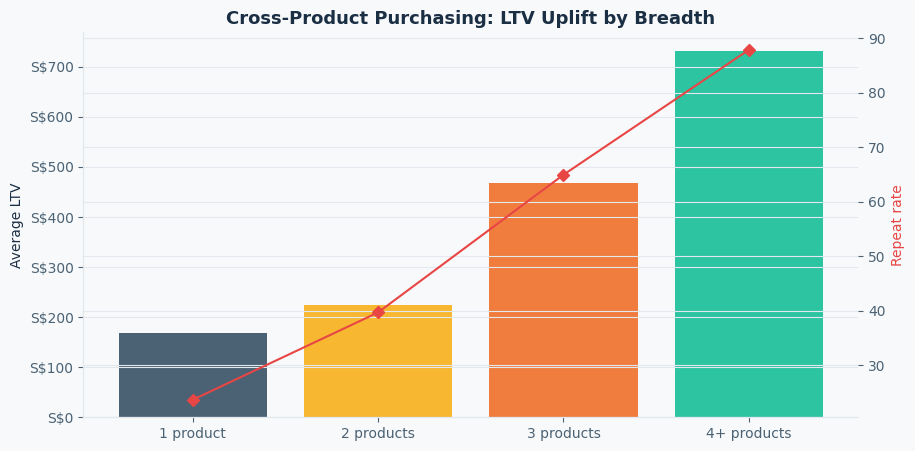

rendered inline: 03a_cross_product_ltv


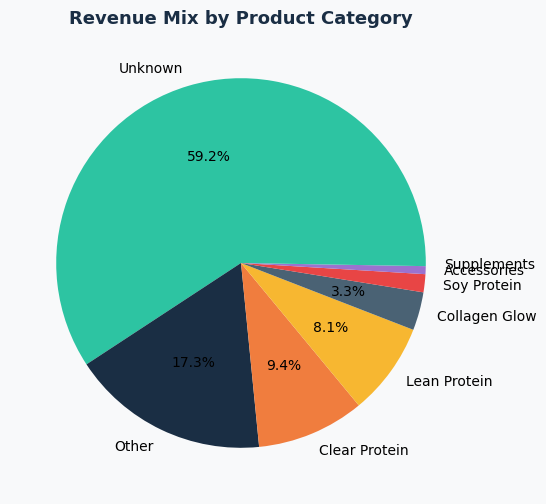

rendered inline: 03b_product_revenue_mix


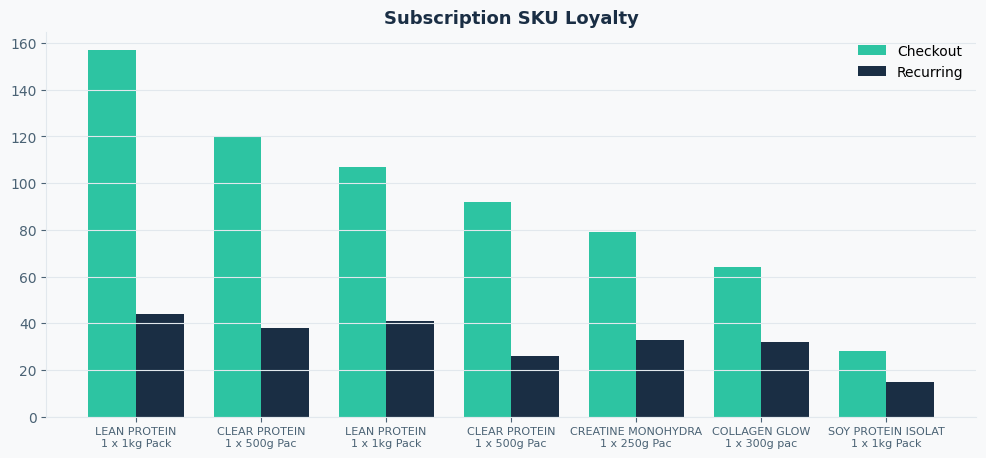

rendered inline: 03c_sku_loyalty


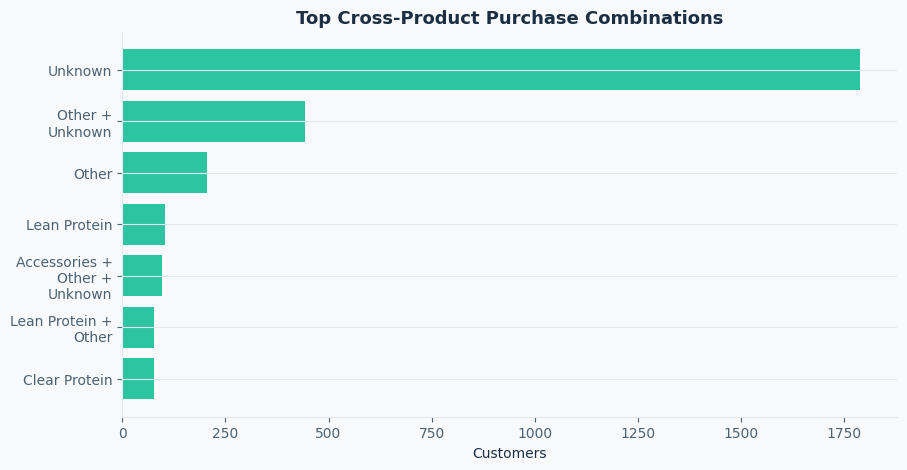

rendered inline: 03d_top_product_combos


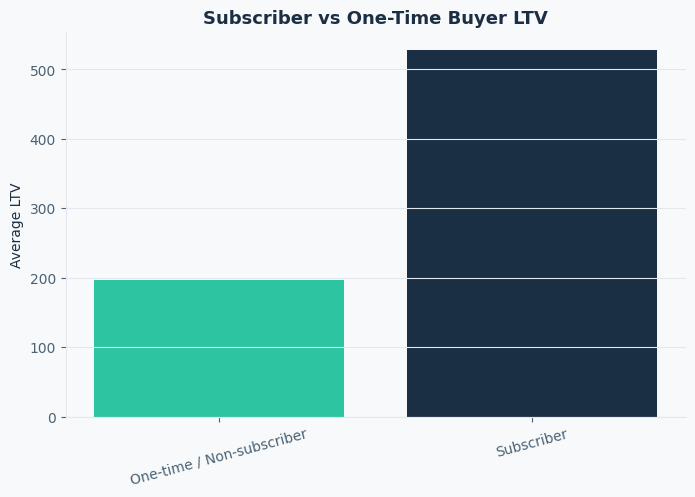

rendered inline: 04a_subscriber_vs_onetime


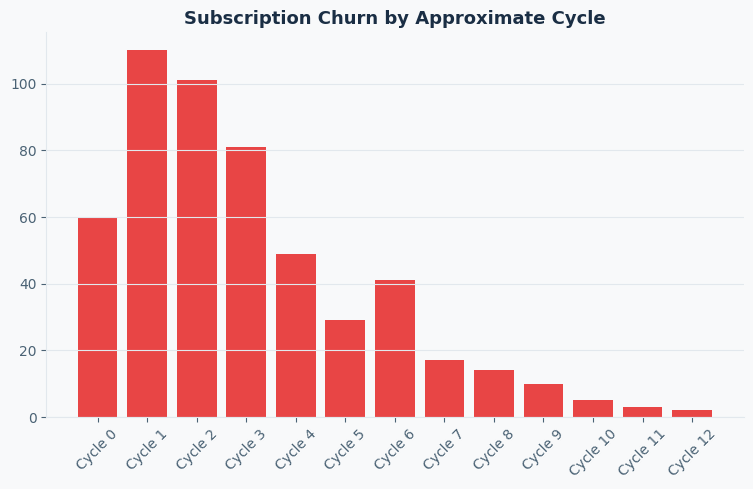

rendered inline: 04b_churn_by_cycle


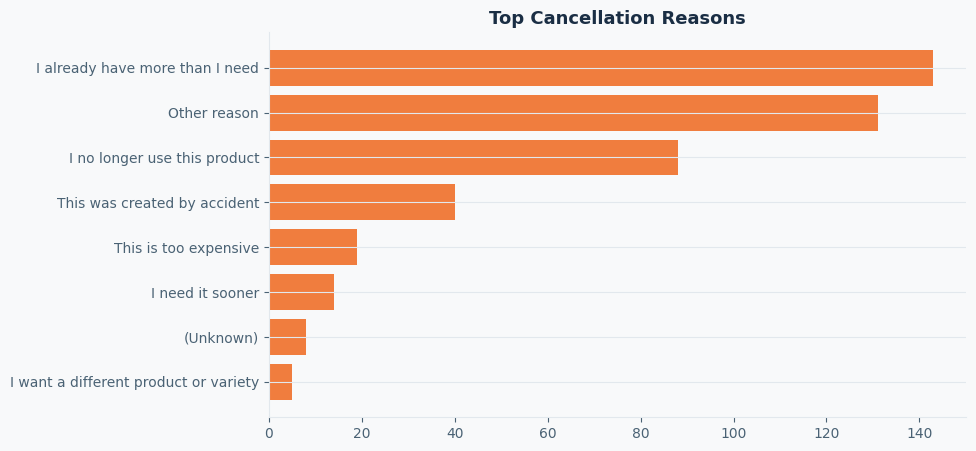

rendered inline: 04c_cancellation_reasons


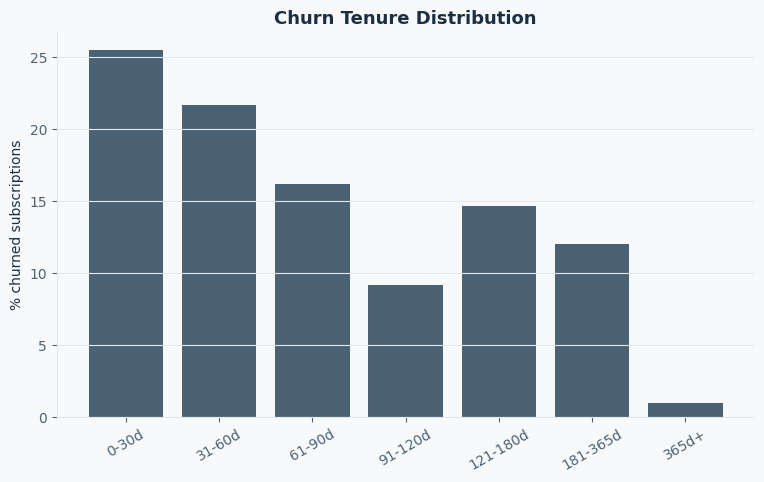

rendered inline: 04d_churn_tenure_distribution


'04d_churn_tenure_distribution'

In [4]:
fig, ax1 = plt.subplots(figsize=(10, 5))
cs = cross_summary.reset_index()
ax1.bar(cs.category_label, cs.avg_ltv, color=[SLATE, GOLD_C, ORANGE, TEAL])
ax1.set_title("Cross-Product Purchasing: LTV Uplift by Breadth")
ax1.set_ylabel("Average LTV")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"S${v:,.0f}"))
ax2 = ax1.twinx()
ax2.plot(cs.category_label, cs.repeat_rate * 100, color=RED, marker="D")
ax2.set_ylabel("Repeat rate", color=RED)
save_chart(fig, "03a_cross_product_ltv")

fig, ax = plt.subplots(figsize=(8, 6))
pr = prod_rev.reset_index().head(8)
ax.pie(pr.total_revenue, labels=pr.product_category, autopct=lambda p: f"{p:.1f}%" if p > 3 else "", colors=CAT_COLORS)
ax.set_title("Revenue Mix by Product Category")
save_chart(fig, "03b_product_revenue_mix")

co = sku_popularity[sku_popularity.type == "checkout"].set_index(["product_title", "variant_title"])["n_customers"].rename("checkout")
re = sku_popularity[sku_popularity.type == "recurring"].set_index(["product_title", "variant_title"])["n_customers"].rename("recurring")
loyalty = pd.concat([co, re], axis=1).dropna().sort_values("checkout", ascending=False).head(7).reset_index()
loyalty["label"] = loyalty.product_title.str.slice(0, 18) + "\n" + loyalty.variant_title.astype(str).str.slice(0, 12)
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(loyalty)); w = 0.38
ax.bar(x-w/2, loyalty.checkout, width=w, color=TEAL, label="Checkout")
ax.bar(x+w/2, loyalty.recurring, width=w, color=NAVY, label="Recurring")
ax.set_xticks(x); ax.set_xticklabels(loyalty.label, fontsize=8)
ax.set_title("Subscription SKU Loyalty")
ax.legend()
save_chart(fig, "03c_sku_loyalty")

rep_ids = set(customers[customers.is_repeat].customer_id)
combos = lines[lines.customer_id.isin(rep_ids)].groupby("customer_id")["product_category"].apply(lambda s: " + ".join(sorted(s.dropna().unique()))).value_counts().head(7)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh([c.replace(" + ", " +\n") for c in combos.index[::-1]], combos.values[::-1], color=TEAL)
ax.set_title("Top Cross-Product Purchase Combinations")
ax.set_xlabel("Customers")
save_chart(fig, "03d_top_product_combos")

fig, ax = plt.subplots(figsize=(8, 5))
sv = sub_vs_ot.reset_index(names="segment")
ax.bar(sv.segment, sv.avg_ltv, color=[TEAL, NAVY])
ax.set_title("Subscriber vs One-Time Buyer LTV")
ax.set_ylabel("Average LTV")
ax.tick_params(axis="x", rotation=15)
save_chart(fig, "04a_subscriber_vs_onetime")

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(cycle.cycle_label, cycle.n_cancellations, color=RED)
ax.set_title("Subscription Churn by Approximate Cycle")
ax.tick_params(axis="x", rotation=45)
save_chart(fig, "04b_churn_by_cycle")

fig, ax = plt.subplots(figsize=(9, 5))
rr = reasons.head(8).sort_values("n")
ax.barh(rr.index.astype(str), rr.n, color=ORANGE)
ax.set_title("Top Cancellation Reasons")
save_chart(fig, "04c_cancellation_reasons")

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(tenure.tenure_bin.astype(str), tenure.pct * 100, color=SLATE)
ax.set_title("Churn Tenure Distribution")
ax.set_ylabel("% churned subscriptions")
ax.tick_params(axis="x", rotation=30)
save_chart(fig, "04d_churn_tenure_distribution")
